# 7. 특징점 검출 및 매칭

**설명 → 코드 → 결과** 순서로 위에서부터 실행한다. ORB로 실습하고 SIFT와의 차이도 비교한다.

- ZIP을 풀고 `Feature_Matching_Notes`에서 노트북을 연다.
- 필요하면 별도 셀에서 `%pip install opencv-python numpy matplotlib` 실행 후 커널을 재시작한다.
- 작업 폴더가 다르면 첫 셀의 ROOT를 수정한다. 옵시디언에서는 MD와 assets를 함께 둔다.

## 7.1 특징점과 특징 기술자

- **특징점(keypoint)**: 다른 사진에서도 다시 찾기 쉬운 위치다. 모서리나 독특한 무늬가 예다.
- **특징 기술자(descriptor)**: 그 점 주변의 생김새를 숫자나 비트로 표현한 것이다.
- 위치만 알아서는 다른 사진의 어느 점인지 비교하기 어렵다. 기술자를 비교해 대응 후보를 찾는다.
- 특징점에는 위치뿐 아니라 크기·방향·응답 강도 같은 정보도 포함될 수 있다.
- 평평한 벽처럼 무늬가 없거나 같은 무늬가 반복되면 대응을 찾기 어렵다.

| 개념 | 비유 | OpenCV 예 |
|---|---|---|
| 특징점 | 지도에서 눈에 띄는 장소 | `kp[i].pt` |
| 기술자 | 그 장소의 생김새 설명 | `des[i]` |
| 매칭 | 두 지도에서 같은 장소 후보 연결 | `DMatch` |

템플릿 매칭은 작은 영상 전체를 위치별로 비교한다. 특징점 매칭은 여러 국소 특징의 대응을 찾으므로 회전·크기 변화에 대응할 여지가 있지만 모든 변화에 강한 것은 아니다.

### 셀 1. 준비

In [1]:
from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT=Path.cwd()
ASSETS=ROOT/'assets'
assert (ASSETS/'Lenna.png').is_file(), 'ROOT를 실습 폴더로 바꾸세요.'
a=cv2.imdecode(np.fromfile(ASSETS/'Lenna.png',np.uint8),cv2.IMREAD_COLOR)
assert a is not None

def show(items,name):
    fig,axs=plt.subplots(1,len(items),figsize=(6*len(items),5),squeeze=False)
    for ax,(title,img) in zip(axs.flat,items):
        ax.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
        ax.set_title(title);ax.axis('off')
    fig.tight_layout();fig.savefig(ASSETS/name,dpi=140)
    plt.show();plt.close(fig)
print('OpenCV:',cv2.__version__)

OpenCV: 5.0.0


### 셀 2. 기하 변환을 아는 두 번째 영상 만들기

레나 전체를 알려진 호모그래피로 변환한다. 실제로 다른 카메라로 촬영한 영상이 아닌 **통제된 합성 실험**이다. 이 실험에서는 한 호모그래피가 정확한 모델이지만, 실제 입체 장면에서는 깊이에 따른 시차로 하나의 호모그래피가 맞지 않을 수 있다. 정답 변환은 검증에만 사용하고 추정에는 제공하지 않는다.

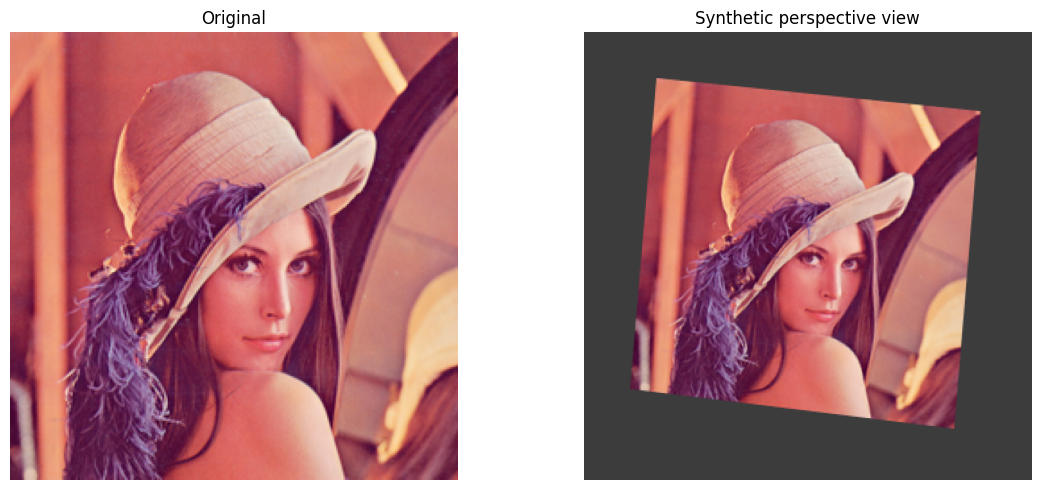

In [2]:
height,width=a.shape[:2]
src_corners=np.float32([[0,0],[width-1,0],[width-1,height-1],[0,height-1]])
dst_corners=np.float32([[55,35],[300,60],[280,300],[35,270]])
H_true=cv2.getPerspectiveTransform(src_corners,dst_corners)
b=cv2.warpPerspective(a,H_true,(340,340),borderValue=(60,60,60))
gray_a=cv2.cvtColor(a,cv2.COLOR_BGR2GRAY)
gray_b=cv2.cvtColor(b,cv2.COLOR_BGR2GRAY)
show([('Original',a),('Synthetic perspective view',b)],'pair.png')

## 7.2 특징점 검출 및 기술자 계산

### ORB와 SIFT

| 항목 | ORB | SIFT |
|---|---|---|
| 기본 아이디어 | FAST 계열 검출·방향·BRIEF 계열 기술자 | 스케일 공간 검출·방향·기울기 분포 기술자 |
| 기본 기술자 | 256비트, 32바이트 | 128차원 실수 벡터 |
| 대표 거리 | 해밍 거리 | L2 거리 |
| 활용 관점 | 비교적 가벼운 처리 | 다양한 스케일·회전 변화의 대응 |

속도·정확도는 이미지와 설정에 따라 달라진다. ORB의 `nfeatures`는 원하는 최대 보유 특징 수에 관한 설정이며 반드시 그만큼 검출되는 것은 아니다.

이번에는 `WTA_K=2`인 ORB를 사용한다. ORB의 `WTA_K=3` 또는 4라면 `NORM_HAMMING2`가 필요하다.

### 셀 3. ORB 검출과 기술자 확인

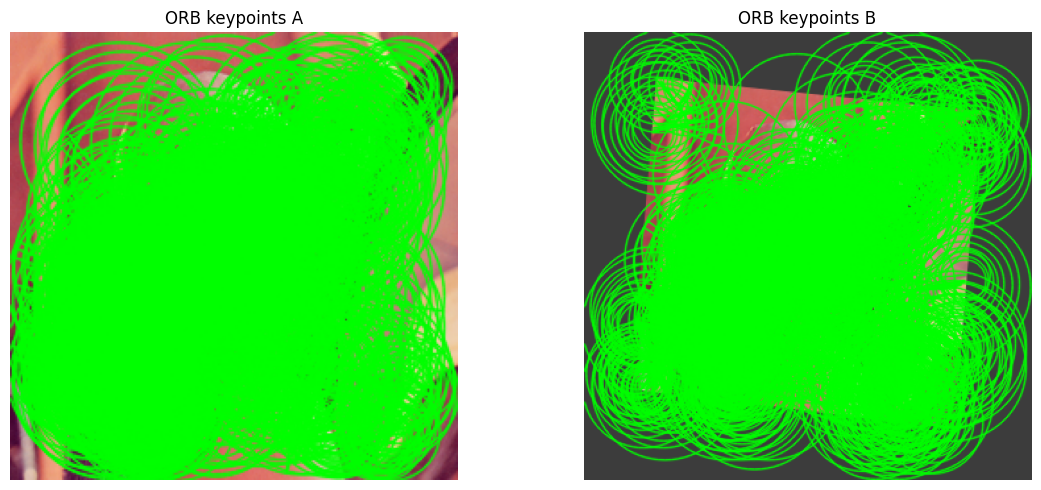

특징점: 1472 1500
기술자: (1472, 32) uint8 (1500, 32) uint8


In [3]:
orb=cv2.ORB_create(nfeatures=1500,scaleFactor=1.2,nlevels=8,edgeThreshold=15,fastThreshold=10,WTA_K=2)
kp_a,des_a=orb.detectAndCompute(gray_a,None)
kp_b,des_b=orb.detectAndCompute(gray_b,None)
if des_a is None or des_b is None or len(des_b)<2:
    raise RuntimeError('매칭할 기술자가 부족합니다. 입력의 무늬와 검출 설정을 확인하세요.')
assert len(kp_a)==len(des_a) and len(kp_b)==len(des_b)
print('특징점:',len(kp_a),len(kp_b))
print('기술자:',des_a.shape,des_a.dtype,des_b.shape,des_b.dtype)
ka=cv2.drawKeypoints(a,kp_a,None,color=(0,255,0),flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
kb=cv2.drawKeypoints(b,kp_b,None,color=(0,255,0),flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
show([('ORB keypoints A',ka),('ORB keypoints B',kb)],'keypoints.png')

## 7.3 특징점 매칭

### 기술자 거리로 후보 찾기

ORB의 해밍 거리는 두 비트열에서 서로 다른 비트 수다.

$$
d_H(p,q)=\sum_i\mathbf{1}[p_i\ne q_i]
$$

SIFT의 대표 거리인 L2는 다음과 같다.

$$
d_2(p,q)=\sqrt{\sum_i(p_i-q_i)^2}
$$

거리가 작을수록 기술자가 비슷하지만, 실제 같은 장소라는 보장은 아니다.

### 최근접 두 후보 비교: 비율 검사

$$
d_1<\tau d_2,\qquad d_1\le d_2
$$

- 1등이 2등보다 충분히 가까우면 남긴다.
- 두 후보의 거리가 비슷하면 모호한 대응으로 본다.
- $\tau=0.75$는 실습 설정이지 정답 확률이나 보편적인 최적값이 아니다.
- 더 작은 값은 일반적으로 더 엄격하게 걸러낸다.
- 비율 검사와 상호 최근접 검사(crossCheck)는 다른 조건이다. 이번에는 `crossCheck=False`와 k=2를 사용한다.

### 셀 4. KNN과 비율 검사

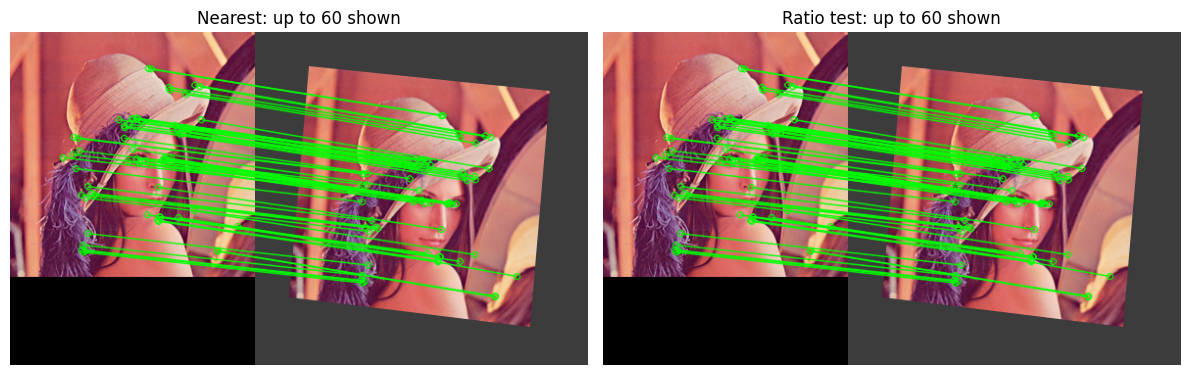

최근접 후보: 1472 비율 검사 통과: 827


In [4]:
matcher=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=False)
pairs=matcher.knnMatch(des_a,des_b,k=2)
nearest=[p[0] for p in pairs if len(p)>0]
good=[]
for pair in pairs:
    if len(pair)<2: continue
    m,n=pair
    if m.distance<0.75*n.distance:good.append(m)
print('최근접 후보:',len(nearest),'비율 검사 통과:',len(good))
# 표시만 상위 60개로 제한하며 RANSAC에는 통과한 전체 대응을 사용한다.
def draw_matches(matches):
    return cv2.drawMatches(a,kp_a,b,kp_b,sorted(matches,key=lambda m:m.distance)[:60],None,
                          matchColor=(0,255,0),flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show([('Nearest: up to 60 shown',draw_matches(nearest)),
      ('Ratio test: up to 60 shown',draw_matches(good))],'matches.png')

## 7.4 잘못된 대응 제거

### RANSAC을 이용한 기하 모델 추정

- 기술자가 비슷한 후보들 가운데 같은 기하 변환으로 설명되는 대응을 찾는다.
- 작은 표본으로 모델을 가정하고, 그 모델에 동의하는 대응을 센다.
- 반복해서 지지가 큰 모델을 찾는다. 여기서는 호모그래피를 추정한다.
- **인라이어**는 현재 모델과 임계값에 맞는 대응이지, 절대적으로 참이라고 인증된 대응이 아니다.
- 가짜 대응이 일관된 패턴을 만들거나 올바른 대응이 너무 적으면 실패할 수 있다.

$$
\begin{bmatrix}u'\\v'\\w'\end{bmatrix}
=H\begin{bmatrix}x\\y\\1\end{bmatrix},\qquad
\hat x'=u'/w',\quad \hat y'=v'/w'
$$

$$
e_i=\sqrt{(x'_i-\hat x'_i)^2+(y'_i-\hat y'_i)^2}
$$

이번 재투영 임계값은 목적 영상 기준 3픽셀이다. 임계값을 크게 하면 부정확한 대응도 포함될 수 있다.

호모그래피에는 일반 위치의 대응점이 최소 4쌍 필요하다. 점이 한 직선에 몰리는 등 퇴화된 배치는 안 되며, 4개가 있다고 신뢰할 수 있는 추정이 보장되지는 않는다.

### 셀 5. 호모그래피와 인라이어 추정

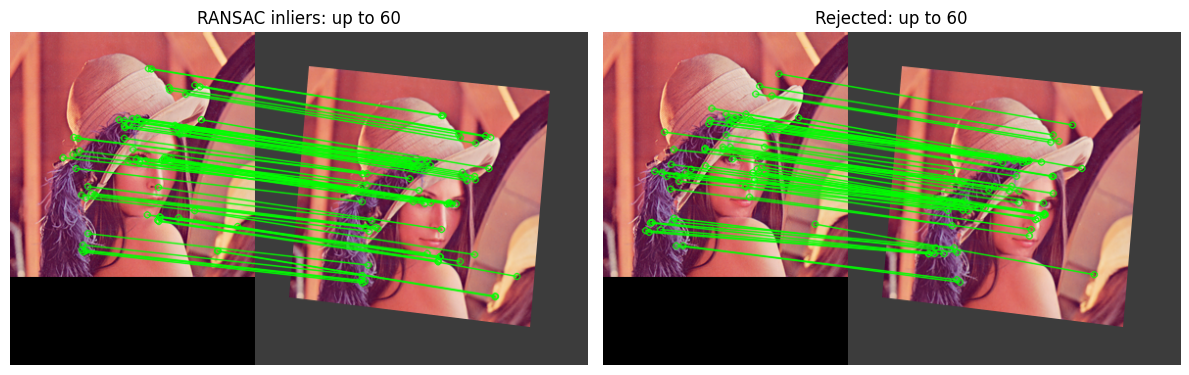

인라이어: 771 아웃라이어: 56


In [5]:
if len(good)<4:
    raise RuntimeError('호모그래피 추정에 필요한 대응이 부족합니다.')
points_a=np.float32([kp_a[m.queryIdx].pt for m in good]).reshape(-1,1,2)
points_b=np.float32([kp_b[m.trainIdx].pt for m in good]).reshape(-1,1,2)
cv2.setRNGSeed(42)
H_est,mask=cv2.findHomography(points_a,points_b,cv2.RANSAC,3.0,maxIters=5000,confidence=0.995)
if H_est is None or mask is None or not np.isfinite(H_est).all():
    raise RuntimeError('기하 모델 추정에 실패했습니다.')
inlier_mask=mask.ravel().astype(bool)
if inlier_mask.sum()<4:raise RuntimeError('유효 인라이어가 부족합니다.')
inliers=[m for m,keep in zip(good,inlier_mask) if keep]
outliers=[m for m,keep in zip(good,inlier_mask) if not keep]
print('인라이어:',len(inliers),'아웃라이어:',len(outliers))
show([('RANSAC inliers: up to 60',draw_matches(inliers)),
      ('Rejected: up to 60',draw_matches(outliers))],'ransac.png')

### 셀 6. 알려진 변환으로 추정 결과 검증

인라이어의 재투영 오차는 모델 적합도를 보여준다. 별도로, 정답 변환과 추정 변환이 영상 내부의 격자점을 어디로 보내는지 비교한다. 이 합성 예제의 성공이 실제 모든 사진에 대한 성능을 뜻하지는 않는다.

주황색은 정답 경계, 초록색은 추정 경계다. 두 선이 겹칠수록 추정 위치가 비슷하다.

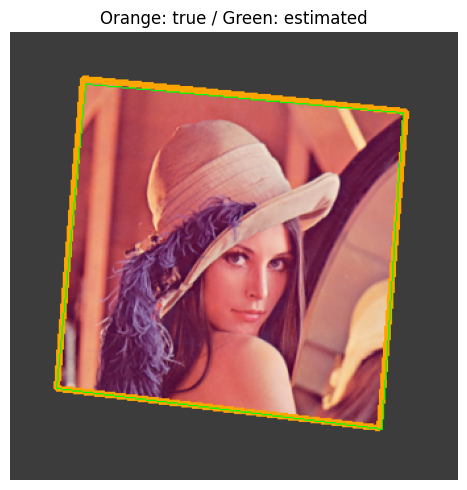

{
  "opencv": "5.0.0",
  "keypoints": [
    1472,
    1500
  ],
  "ratio_matches": 827,
  "inliers": 771,
  "outliers": 56,
  "inlier_median_reprojection_px": 0.8571128845214844,
  "grid_median_error_px": 0.646217942237854,
  "grid_max_error_px": 3.446655750274658
}


In [6]:
pred=cv2.perspectiveTransform(points_a,H_est)
errors=np.linalg.norm(pred-points_b,axis=2).ravel()
xx,yy=np.meshgrid(np.linspace(20,width-21,8),np.linspace(20,height-21,8))
grid=np.stack([xx.ravel(),yy.ravel()],axis=1).astype(np.float32).reshape(-1,1,2)
true_grid=cv2.perspectiveTransform(grid,H_true)
est_grid=cv2.perspectiveTransform(grid,H_est)
grid_error=np.linalg.norm(true_grid-est_grid,axis=2).ravel()
outline=cv2.perspectiveTransform(src_corners.reshape(-1,1,2),H_est)
marked=b.copy()
cv2.polylines(marked,[np.rint(dst_corners).astype(np.int32)],True,(0,165,255),3)
cv2.polylines(marked,[np.rint(outline).astype(np.int32)],True,(0,255,0),1)
show([('Orange: true / Green: estimated',marked)],'homography.png')
summary={'opencv':cv2.__version__,'keypoints':[len(kp_a),len(kp_b)],'ratio_matches':len(good),
         'inliers':len(inliers),'outliers':len(outliers),
         'inlier_median_reprojection_px':float(np.median(errors[inlier_mask])),
         'grid_median_error_px':float(np.median(grid_error)),
         'grid_max_error_px':float(grid_error.max())}
print(json.dumps(summary,indent=2))
assert np.median(grid_error)<5, '이 합성 예제에서 추정 오차가 큽니다.'
(ROOT/'results.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
np.savez(ROOT/'homography_results.npz',H_true=H_true,H_est=H_est,inlier_mask=inlier_mask,
         points_a=points_a,points_b=points_b)

### 셀 7. 단색 입력과 SIFT 기술자 확인

단색에서 특징점이 없을 때를 확인한다. SIFT는 검출·기술자 모양만 비교하며, 앞의 ORB 결과로 SIFT의 정확도를 평가하지 않는다. SIFT로 매칭을 바꿀 때는 기술자뿐 아니라 거리도 L2로 바꿔야 한다.

In [7]:
blank=np.full((100,100),128,np.uint8)
blank_kp,blank_des=orb.detectAndCompute(blank,None)
assert len(blank_kp)==0 and blank_des is None
print('단색 입력의 기술자 없음 처리 확인')
if hasattr(cv2,'SIFT_create'):
    sift=cv2.SIFT_create(nfeatures=1000)
    skp,sdes=sift.detectAndCompute(gray_a,None)
    print('SIFT 특징점:',len(skp),'기술자:',None if sdes is None else (sdes.shape,str(sdes.dtype)))
    # SIFT 매칭에서는 cv2.BFMatcher(cv2.NORM_L2)를 사용한다.
else:
    print('현재 빌드에 SIFT가 없습니다. ORB 실습 결과는 그대로 확인 가능합니다.')

단색 입력의 기술자 없음 처리 확인
SIFT 특징점: 283 기술자: ((283, 128), 'float32')


## 실패를 해석하는 방법

| 증상 | 확인할 것 |
|---|---|
| 특징점이 거의 없음 | 텍스처·해상도·흐림·검출 임계값 |
| 비율 검사 후 대응이 부족 | 겹치는 영역·반복 무늬·변환 크기 |
| 인라이어가 적음 | 잘못된 대응·기하 모델의 적합성 |
| 인라이어는 많지만 경계가 이상함 | 점의 공간 분포·퇴화 배치·반복 패턴 |
| 실제 입체 장면에서 오차가 큼 | 깊이 차이와 시차, 다른 기하 모델 필요 여부 |

호모그래피는 평면 또는 적절한 카메라 회전 상황 등에 알맞다. 일반적인 입체 장면에서는 기본행렬·필수행렬 등 다른 모델을 고려한다. RANSAC이 모델 선택의 잘못까지 자동 해결하지는 않는다.

## 확인 질문

- [ ] 특징점의 위치와 기술자를 구분하는가?
- [ ] ORB와 SIFT의 거리 함수를 구분하는가?
- [ ] 비율 검사가 정확도 75%를 뜻하지 않음을 이해했는가?
- [ ] 인라이어가 모델과 임계값에 따른 판정임을 이해했는가?
- [ ] 정답 변환은 추정이 아닌 검증에만 사용했음을 확인했는가?

## 참고 문서

- [OpenCV — Feature Matching](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)
- [OpenCV — Feature Matching and Homography](https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html)

레나는 사용자 제공 파일이다. 두 번째 영상은 코드로 생성한 합성 변환이며 실제 독립 촬영 데이터가 아니다.


## 실행 확인 방식

제공 환경에서 Jupyter 커널의 소켓 생성이 제한되어, 코드 셀을 하나의 Python 실행 공간에서 순서대로 실행하고 출력·그림을 노트북에 저장했다. 모든 코드 셀과 검증문은 통과했다. 실제 Jupyter 커널에서의 Run All은 이 환경에서 확인하지 못했다.